In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,0.461898,0.499075,0.224562,0.350904,0.324971,0.329524,0.197367,0.298726,0.054040,0.236549,...,0.103491,0.073737,0.246552,0.828332,0.000000,0.146370,0.174091,0.088609,0.117134,0.129992
1,0.829873,0.220565,0.009452,0.123069,0.098241,0.105313,0.112770,0.099559,0.007092,0.167245,...,0.293049,0.527489,0.491288,0.381507,0.000000,0.627983,0.456736,0.501821,0.522593,0.262640
2,0.724738,0.602909,0.323454,0.428640,0.431058,0.394219,0.289334,0.430358,0.098901,0.416103,...,0.000000,0.110703,0.324605,0.844232,0.066875,0.181100,0.097341,0.000000,0.100822,0.147717
3,0.839273,0.284579,0.030943,0.135806,0.084805,0.090131,0.164684,0.145809,0.008753,0.182093,...,0.251423,0.433705,0.502847,0.418154,0.000000,0.237064,0.464144,0.000000,0.385850,0.343574
4,0.814436,0.345369,0.110132,0.254489,0.165934,0.259726,0.189977,0.222333,0.014595,0.290508,...,0.000000,0.125399,0.481924,0.337066,0.386334,0.644928,0.518081,0.572624,0.718823,0.543835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.583257,0.479962,0.141584,0.233413,0.215527,0.254755,0.126540,0.198864,0.026267,0.194288,...,0.000000,0.098308,0.242188,0.782563,0.000000,0.103713,0.242682,0.000000,0.109365,0.126149
135,0.702369,0.831212,0.347022,0.337469,0.361149,0.408289,0.267366,0.351455,0.086360,0.325084,...,0.033028,0.123853,0.382084,0.730419,0.000000,0.294427,0.187835,0.113114,0.172107,0.234892
136,0.720597,0.686245,0.243971,0.279727,0.190136,0.307936,0.291232,0.251133,0.050921,0.280811,...,0.000000,0.020534,0.134210,0.895114,0.000000,0.065712,0.175602,0.000000,0.091309,0.191396
137,0.504667,0.427891,0.225551,0.400455,0.339899,0.348108,0.222720,0.342192,0.061894,0.290628,...,0.000000,0.064801,0.319657,0.711658,0.000000,0.226079,0.265036,0.077871,0.177208,0.265078


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

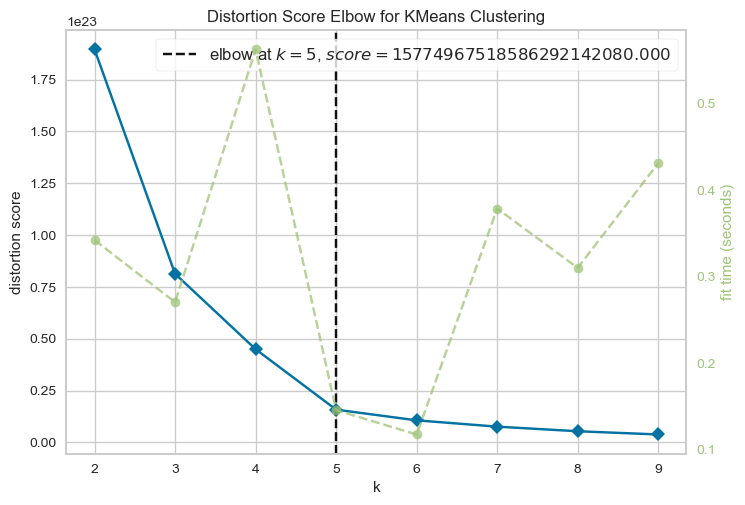

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: glcm_DifferenceVariance_d_1_PET_b2, Coefficient: 6.18036956079333


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: gldm_DependenceNonUniformity_d_1_PET_c04, Coefficient: -43.241825753222614


...

Cluster 2: Most important feature: glrlm_GrayLevelVariance_CT_b20, Coefficient: 16.851154889192916


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: gldm_HighGrayLevelEmphasis_d_1_CT_c16, Coefficient: -12.835468528658575


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: glrlm_HighGrayLevelRunEmphasis_CT_b20, Coefficient: 9.327418835409672


In [22]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Standardization

In [23]:
# Do the standardization for X_fs_fi
scaler = MinMaxScaler() 
X_new_std= scaler.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = scaler.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [24]:
X_new

,glcm_DifferenceVariance_d_1_PET_b2,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,glrlm_HighGrayLevelRunEmphasis_CT_b20
0,0.227590,1132.849143,22.310788,93.931911,2015.370464
1,0.155008,177.023053,20.557318,119.398184,1251.642438
2,0.136431,1888.886026,21.092104,115.381455,2635.777575
3,0.108845,211.940366,22.786001,163.234342,2042.289891
4,0.157862,346.285373,29.182742,206.510961,1724.990470
...,...,...,...,...,...
134,0.195705,517.454513,4.906583,169.232304,844.181781
135,0.117197,1592.627288,16.015030,80.531748,1623.604073
136,0.233447,1021.684898,24.706900,118.671714,1498.951442
137,0.138072,1295.643252,5.157909,196.953388,1030.596870


In [25]:
X_new_std

,glcm_DifferenceVariance_d_1_PET_b2,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,glrlm_HighGrayLevelRunEmphasis_CT_b20
0,0.481032,0.016668,0.072353,0.358598,0.614836
1,0.291855,0.001362,0.066055,0.464356,0.376067
2,0.243434,0.028776,0.067975,0.447675,0.808798
3,0.171534,0.001921,0.074060,0.646401,0.623252
4,0.299294,0.004072,0.097036,0.826122,0.524053
...,...,...,...,...,...
134,0.397928,0.006813,0.009840,0.671309,0.248680
135,0.193303,0.024031,0.049739,0.302950,0.492356
136,0.496300,0.014888,0.080959,0.461339,0.453385
137,0.247712,0.019275,0.010743,0.786431,0.306960


In [26]:
MAASTRO_new

,glcm_DifferenceVariance_d_1_PET_b2,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,glrlm_HighGrayLevelRunEmphasis_CT_b20
0,0.223527,2486.104657,14.212485,191.354768,1430.631678
1,0.159073,1223.288872,54.975356,96.743052,2918.814266
2,0.207995,1128.604578,27.032891,188.107697,1915.190474
3,0.160225,758.871164,146.781623,89.452126,2994.672783
4,0.143606,1924.271323,9.468732,112.193823,2143.727153
...,...,...,...,...,...
94,0.561268,803.301749,40.637943,48.789895,1932.791818
95,0.197000,1121.977787,143.812625,171.261283,2454.568498
96,0.127361,2157.170772,22.317077,196.941562,2780.351060
97,0.203342,1866.857748,20.533289,103.424583,2057.575424


In [27]:
MAASTRO_new_std

,glcm_DifferenceVariance_d_1_PET_b2,gldm_DependenceNonUniformity_d_1_PET_c04,glrlm_GrayLevelVariance_CT_b20,gldm_HighGrayLevelEmphasis_d_1_CT_c16,glrlm_HighGrayLevelRunEmphasis_CT_b20
0,0.470445,0.038340,0.043265,0.763181,0.432026
1,0.302450,0.018117,0.189678,0.370273,0.897285
2,0.429960,0.016600,0.089314,0.749696,0.583516
3,0.305452,0.010679,0.519430,0.339995,0.921001
4,0.262135,0.029342,0.026226,0.434437,0.654965
...,...,...,...,...,...
94,1.350739,0.011391,0.138181,0.171131,0.589019
95,0.401303,0.016494,0.508766,0.679736,0.752145
96,0.219795,0.033072,0.072375,0.786382,0.853997
97,0.417832,0.028423,0.065968,0.398020,0.628031


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 14:14:11,917] A new study created in memory with name: no-name-603d7cfb-262f-441f-b197-31d7c79235ed


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7053571428571429
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7257383966244726


[I 2024-04-15 14:14:12,420] A new study created in memory with name: no-name-4a03903a-3871-405b-9aff-8b9f8bacbaad


Fold 5 C-index: 0.6666666666666666
[I 2024-04-15 14:14:12,412] Trial 0 finished with value: 0.6799802487162874 and parameters: {}. Best is trial 0 with value: 0.6799802487162874.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6799802487162874], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 12, 50838), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 12, 412493), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6799802487162874


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.20682638878205584
Fold 2 IBS: 0.1884900508861934
Fold 3 IBS: 0.17513129575202152
Fold 4 IBS: 0.19303745954177354
Fold 5 IBS: 0.2315636970026946
[I 2024-04-15 14:14:12,934] Trial 0 finished with value: 0.1990097783929478 and parameters: {}. Best is trial 0 with value: 0.1990097783929478.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1990097783929478], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 12, 460036), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 12, 934079), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.1990097783929478


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.68
train_ibs:  0.199


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.644
IBS score: 0.205


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 14:14:13,605] A new study created in memory with name: no-name-729745ce-195d-446f-b30d-64554d4fe2a5


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-15 14:14:13,835] A new study created in memory with name: no-name-b10a91de-9ffc-4e00-be11-e150c3d9a20e


Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.6763392857142857
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6056338028169014
[I 2024-04-15 14:14:13,813] Trial 0 finished with value: 0.6538808619162345 and parameters: {}. Best is trial 0 with value: 0.6538808619162345.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6538808619162345], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 13, 649176), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 13, 813448), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6538808619162345


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652135259654
Fold 2 IBS: 0.22157791582911082
Fold 3 IBS: 0.20453594627693092
Fold 4 IBS: 0.22473803926339372
Fold 5 IBS: 0.2181243152631878
[I 2024-04-15 14:14:14,065] Trial 0 finished with value: 0.216590547597044 and parameters: {}. Best is trial 0 with value: 0.216590547597044.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.216590547597044], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 13, 874295), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 14, 65283), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.216590547597044


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.654
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.611


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 14:14:14,342] A new study created in memory with name: no-name-05e666e9-988a-423d-aac0-2b2dec2e024d


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7426160337552743


[I 2024-04-15 14:14:14,797] A new study created in memory with name: no-name-227807a6-8c5a-4bea-9f72-0840f25df3dd


Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:14,782] Trial 0 finished with value: 0.6806310947205833 and parameters: {}. Best is trial 0 with value: 0.6806310947205833.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6806310947205833], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 14, 374498), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 14, 781777), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6806310947205833


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.20658050267994918
Fold 2 IBS: 0.18852236895992613
Fold 3 IBS: 0.17492744621784564
Fold 4 IBS: 0.19216572164071472
Fold 5 IBS: 0.23193642507212076
[I 2024-04-15 14:14:15,346] Trial 0 finished with value: 0.1988264929141113 and parameters: {}. Best is trial 0 with value: 0.1988264929141113.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1988264929141113], datetime_start=datetime.datetime(2024, 4, 15, 14, 14, 14, 836831), datetime_complete=datetime.datetime(2024, 4, 15, 14, 14, 15, 346640), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.1988264929141113


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.681
train_ibs:  0.199


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.641


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.206


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 14:14:15,727] A new study created in memory with name: no-name-b3e6dc3b-4520-4653-abd6-9407ce07656c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7426160337552743
Fold 5 C-index: 0.6572769953051644
[I 2024-04-15 14:14:16,237] Trial 0 finished with value: 0.6796921275844331 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6796921275844331.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:16,713] Trial 1 finished with value: 0.6797872128640432 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6797872128640432.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7008928571428571
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:17,164] Trial 2 finished with value: 0.6806800700069003 and parameters: {'l1_ratio': 0.22692876841884668}. Be

Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.7932489451476793
Fold 5 C-index: 0.6009389671361502
[I 2024-04-15 14:14:28,473] Trial 24 finished with value: 0.6655736405163534 and parameters: {'l1_ratio': 0.007782481870732605}. Best is trial 14 with value: 0.6829551946712654.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:29,173] Trial 25 finished with value: 0.6797872128640432 and parameters: {'l1_ratio': 0.37623969522113426}. Best is trial 14 with value: 0.6829551946712654.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7008928571428571
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:30,007] Trial 26 finished with value: 0.6806800700069003 and parameters: {'l1_ratio': 0.19569911866323234}. Best i

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7426160337552743
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:43,094] Trial 48 finished with value: 0.6806310947205833 and parameters: {'l1_ratio': 0.7768768486379835}. Best is trial 14 with value: 0.6829551946712654.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7008928571428571
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:44,065] Trial 49 finished with value: 0.6899627704288412 and parameters: {'l1_ratio': 0.1787373343293302}. Best is trial 49 with value: 0.6899627704288412.
Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-15 14:14:44,690] Trial 50 finished with value: 0.6797872128640432 and parameters: {'l1_ratio': 0.41653985858071785}

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.20646303637111876
Fold 2 IBS: 0.1886159087704363
Fold 3 IBS: 0.1749096366309284
Fold 4 IBS: 0.1922286247690633
Fold 5 IBS: 0.23163838183981728
[I 2024-04-15 14:15:34,323] Trial 0 finished with value: 0.1987711176762728 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.1987711176762728.
Fold 1 IBS: 0.20636947709342576
Fold 2 IBS: 0.18874844507968122
Fold 3 IBS: 0.17491530462485327
Fold 4 IBS: 0.1923316751893266
Fold 5 IBS: 0.23119713497123545
[I 2024-04-15 14:15:35,733] Trial 1 finished with value: 0.19871240739170445 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.19871240739170445.
Fold 1 IBS: 0.2063309347955603
Fold 2 IBS: 0.1887535307098964
Fold 3 IBS: 0.17492338987265124
Fold 4 IBS: 0.19231289264665744
Fold 5 IBS: 0.2311551212830581
[I 2024-04-15 14:15:36,860] Trial 2 finished with value: 0.19869517386156468 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.19869517386156468.

Fold 1 IBS: 0.20635070617653725
Fold 2 IBS: 0.18876896924177233
Fold 3 IBS: 0.17491824713476858
Fold 4 IBS: 0.19235834233245033
Fold 5 IBS: 0.2311166092706329
[I 2024-04-15 14:16:01,350] Trial 25 finished with value: 0.19870257483123227 and parameters: {'l1_ratio': 0.20091168655110367}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.20635702317849128
Fold 2 IBS: 0.18875714806997704
Fold 3 IBS: 0.17491079528034512
Fold 4 IBS: 0.19231684227968612
Fold 5 IBS: 0.23121492677667768
[I 2024-04-15 14:16:02,866] Trial 26 finished with value: 0.19871134711703545 and parameters: {'l1_ratio': 0.27923041721666114}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.20640538059622512
Fold 2 IBS: 0.18868640212503893
Fold 3 IBS: 0.17490441899383807
Fold 4 IBS: 0.1922547840015211
Fold 5 IBS: 0.2313980529476619
[I 2024-04-15 14:16:04,181] Trial 27 finished with value: 0.19872980773285703 and parameters: {'l1_ratio': 0.4698787873988891}. Best is trial 2 with value: 0.198695173

Fold 1 IBS: 0.21333889665891687
Fold 2 IBS: 0.22015833467552526
Fold 3 IBS: 0.20342021177666572
Fold 4 IBS: 0.22261430352987369
Fold 5 IBS: 0.21814838049743476
[I 2024-04-15 14:16:26,114] Trial 50 finished with value: 0.21553602542768324 and parameters: {'l1_ratio': 0.10386265242796582}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.20633573456798407
Fold 2 IBS: 0.1887778136427761
Fold 3 IBS: 0.17491074241715507
Fold 4 IBS: 0.19232998937836548
Fold 5 IBS: 0.2311490912602372
[I 2024-04-15 14:16:27,989] Trial 51 finished with value: 0.1987006742533036 and parameters: {'l1_ratio': 0.2114115848967811}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.2063626377676466
Fold 2 IBS: 0.1887606903514246
Fold 3 IBS: 0.17492258861709464
Fold 4 IBS: 0.1923142451764714
Fold 5 IBS: 0.23113251775547985
[I 2024-04-15 14:16:29,068] Trial 52 finished with value: 0.1986985359336234 and parameters: {'l1_ratio': 0.20592349796549447}. Best is trial 2 with value: 0.1986951738615

Fold 1 IBS: 0.2129489869995396
Fold 2 IBS: 0.2193148393032638
Fold 3 IBS: 0.1749161637623428
Fold 4 IBS: 0.22147135857865635
Fold 5 IBS: 0.23111820299268626
[I 2024-04-15 14:16:55,235] Trial 75 finished with value: 0.21195391032729774 and parameters: {'l1_ratio': 0.16496357453014723}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.21356715007936758
Fold 2 IBS: 0.22066066152377486
Fold 3 IBS: 0.2038207692340334
Fold 4 IBS: 0.22333955361822774
Fold 5 IBS: 0.21813590681261227
[I 2024-04-15 14:16:56,471] Trial 76 finished with value: 0.21590480825360317 and parameters: {'l1_ratio': 0.06726614639012166}. Best is trial 2 with value: 0.19869517386156468.
Fold 1 IBS: 0.2132267335805172
Fold 2 IBS: 0.21991382565727172
Fold 3 IBS: 0.20322291026432995
Fold 4 IBS: 0.22227286875003496
Fold 5 IBS: 0.23106515608889502
[I 2024-04-15 14:16:57,112] Trial 77 finished with value: 0.21794029886820976 and parameters: {'l1_ratio': 0.12161823391854744}. Best is trial 2 with value: 0.1986951738

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.69
train_ibs:  0.199


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.1787373343293302)

test_cindex : 0.642


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.22692876841884668)

test_ibs:  0.206


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 14:17:27,347] A new study created in memory with name: no-name-bfe3e8ad-5ae8-41d6-bace-8e66a0bc260c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5735930735930735
Fold 2 C-index: 0.65625
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6384976525821596
[I 2024-04-15 14:17:41,155] Trial 0 finished with value: 0.6323303442918846 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6323303442918846.
Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.5803571428571429
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.6244131455399061
[I 2024-04-15 14:17:49,181] Trial 1 finished with value: 0.6302306659061298 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_featur

Fold 5 C-index: 0.7488262910798122
[I 2024-04-15 14:19:36,518] Trial 15 finished with value: 0.7094882426341256 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 1, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.9845383513661248, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 14 with value: 0.7267254021091735.
Fold 1 C-index: 0.5844155844155844
Fold 2 C-index: 0.7566964285714286
Fold 3 C-index: 0.6838235294117647
Fold 4 C-index: 0.7194092827004219
Fold 5 C-index: 0.7699530516431925
[I 2024-04-15 14:19:37,023] Trial 16 finished with value: 0.7028595753484784 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 12, 'oob_score': True, 'max_samples': 0.9623404018358415, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10353058064578669, 'warm_start': True}. Best is trial 14 with value: 0.72672540210917

Fold 1 C-index: 0.577922077922078
Fold 2 C-index: 0.7834821428571429
Fold 3 C-index: 0.7303921568627451
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.755868544600939
[I 2024-04-15 14:19:56,625] Trial 30 finished with value: 0.7222756004823363 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 5, 'n_estimators': 50, 'oob_score': True, 'max_samples': 0.8015511241471713, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.18579705931910293, 'warm_start': True}. Best is trial 25 with value: 0.7438863857347019.
Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.7254901960784313
Fold 4 C-index: 0.7932489451476793
Fold 5 C-index: 0.8169014084507042
[I 2024-04-15 14:19:58,094] Trial 31 finished with value: 0.7385566813639345 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 136, 'oob_score': True, 'max_samples': 0.8949679048269459, 

...

Fold 1 IBS: 0.23648723506965133
Fold 2 IBS: 0.19164622873279608
Fold 3 IBS: 0.17046511178478582
Fold 4 IBS: 0.1737507967471461
Fold 5 IBS: 0.21288618634540593
[I 2024-04-15 14:24:34,746] Trial 32 finished with value: 0.19704711173595707 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 188, 'oob_score': False, 'max_samples': 0.8599067515433989, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.02256021064026959}. Best is trial 31 with value: 0.19414705984132244.
Fold 1 IBS: 0.20003990381859085
Fold 2 IBS: 0.18405288293539343
Fold 3 IBS: 0.17140262738114095
Fold 4 IBS: 0.17861708957105585
Fold 5 IBS: 0.21028194888136437
[I 2024-04-15 14:24:40,871] Trial 33 finished with value: 0.18887889051750908 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 252, 'oob_score': False, 'max_samples': 0.985825799140897, 'max_features': 'auto', 'min_weight_fraction

Fold 5 IBS: 0.22633525354492837
[I 2024-04-15 14:26:08,538] Trial 47 finished with value: 0.2108815481369235 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 6, 'n_estimators': 258, 'oob_score': True, 'max_samples': 0.8784884357317835, 'max_features': None, 'min_weight_fraction_leaf': 0.09308124298250717}. Best is trial 37 with value: 0.18493357424740237.
Fold 1 IBS: 0.2424833706619997
Fold 2 IBS: 0.20712763334704865
Fold 3 IBS: 0.2002191710789286
Fold 4 IBS: 0.18624624762799052
Fold 5 IBS: 0.22109266305989247
[I 2024-04-15 14:26:19,761] Trial 48 finished with value: 0.21143381715517195 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 4, 'n_estimators': 301, 'oob_score': False, 'max_samples': 0.9497003661711719, 'max_features': None, 'min_weight_fraction_leaf': 0.133351221752852}. Best is trial 37 with value: 0.18493357424740237.
Fold 1 IBS: 0.21858915210771707
Fold 2 IBS: 0.2065843302

Fold 1 IBS: 0.20492385297896998
Fold 2 IBS: 0.17134359910592728
Fold 3 IBS: 0.17624391633427683
Fold 4 IBS: 0.172675541565926
Fold 5 IBS: 0.20823631419054042
[I 2024-04-15 14:27:18,298] Trial 63 finished with value: 0.1866846448351281 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 33, 'oob_score': False, 'max_samples': 0.8426681254852635, 'max_features': None, 'min_weight_fraction_leaf': 0.0035948722478167175}. Best is trial 37 with value: 0.18493357424740237.
Fold 1 IBS: 0.20133675058570305
Fold 2 IBS: 0.2064124797880227
Fold 3 IBS: 0.20762397934171195
Fold 4 IBS: 0.19909052678509326
Fold 5 IBS: 0.2206087389747463
[I 2024-04-15 14:27:18,874] Trial 64 finished with value: 0.20701449509505548 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 18, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 3, 'oob_score': False, 'max_samples': 0.8436714012272155, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.2120559566666981
Fold 2 IBS: 0.16720167284612733
Fold 3 IBS: 0.1826300890466335
Fold 4 IBS: 0.17558516860944182
Fold 5 IBS: 0.21197532929339985
[I 2024-04-15 14:29:04,167] Trial 79 finished with value: 0.1898896432924601 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 16, 'n_estimators': 42, 'oob_score': False, 'max_samples': 0.8647687694208672, 'max_features': None, 'min_weight_fraction_leaf': 0.04921203626734488}. Best is trial 37 with value: 0.18493357424740237.
Fold 1 IBS: 0.22336739239669434
Fold 2 IBS: 0.201929815522335
Fold 3 IBS: 0.18099291087834662
Fold 4 IBS: 0.1960214449579138
Fold 5 IBS: 0.21570567715238737
[I 2024-04-15 14:29:08,091] Trial 80 finished with value: 0.20360344818153542 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 154, 'oob_score': False, 'max_samples': 0.37703659520841803, 'max_features': 'sqrt', 'min_weight_fraction_leaf':

Fold 5 IBS: 0.21020778716315294
[I 2024-04-15 14:30:53,229] Trial 94 finished with value: 0.19396650602953383 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 159, 'oob_score': False, 'max_samples': 0.9425398963265169, 'max_features': None, 'min_weight_fraction_leaf': 0.013899127060486667}. Best is trial 91 with value: 0.18487823358460836.
Fold 1 IBS: 0.20229013677403102
Fold 2 IBS: 0.17051862499255563
Fold 3 IBS: 0.1864027863897819
Fold 4 IBS: 0.17284463799714558
Fold 5 IBS: 0.21152063980875022
[I 2024-04-15 14:30:54,823] Trial 95 finished with value: 0.18871536519245286 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 27, 'oob_score': False, 'max_samples': 0.8685350303562097, 'max_features': None, 'min_weight_fraction_leaf': 0.02316758206973385}. Best is trial 91 with value: 0.18487823358460836.
Fold 1 IBS: 0.22476510013854512
Fold 2 IBS: 0.18663

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.795
train_ibs:  0.185


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_features='auto', max_leaf_nodes=6,
                     max_samples=0.776441105503509, min_samples_leaf=5,
                     min_samples_split=11,
                     min_weight_fraction_leaf=0.02998082859372915,
                     n_estimators=175, random_state=123, warm_start=True)

test_cindex:  0.622


RandomSurvivalForest(max_depth=2, max_features=None, max_leaf_nodes=20,
                     max_samples=0.9461281301626344, min_samples_split=14,
                     min_weight_fraction_leaf=0.03280603928581709,
                     n_estimators=174, random_state=123)

test_ibs:  0.208


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 14:31:33,410] A new study created in memory with name: no-name-9d77c27c-19c0-43a3-b5f6-4ae782642e67


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7763713080168776
Fold 5 C-index: 0.7183098591549296
[I 2024-04-15 14:31:36,308] Trial 0 finished with value: 0.7200273971725839 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7200273971725839.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:31:43,551] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 4 C-index: 0.7046413502109705
Fold 5 C-index: 0.676056338028169
[I 2024-04-15 14:32:31,712] Trial 15 finished with value: 0.6828988322747696 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7418694989381674.
Fold 1 C-index: 0.564935064935065
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.7058823529411765
Fold 4 C-index: 0.7194092827004219
Fold 5 C-index: 0.6314553990610329
[I 2024-04-15 14:32:35,249] Trial 16 finished with value: 0.660050705641825 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is t

Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.7549019607843137
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.8215962441314554
[I 2024-04-15 14:33:27,974] Trial 30 finished with value: 0.7536969504247671 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 278, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.05879574792157449}. Best is trial 30 with value: 0.7536969504247671.
Fold 1 C-index: 0.5670995670995671
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.8354430379746836
Fold 5 C-index: 0.8028169014084507
[I 2024-04-15 14:33:29,467] Trial 31 finished with value: 0.7418772234253919 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 281, 'oob_score': False, 'warm_start': True, 'max_features': 

...

Fold 1 IBS: 0.21178861329008197
Fold 2 IBS: 0.21365971461980846
Fold 3 IBS: 0.19860048812542835
Fold 4 IBS: 0.2150829048206566
Fold 5 IBS: 0.21371513996109862
[I 2024-04-15 14:40:23,637] Trial 30 finished with value: 0.21056937216341481 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.20530475239315849, 'min_weight_fraction_leaf': 0.020774921326658265}. Best is trial 12 with value: 0.20535751838755037.
Fold 1 IBS: 0.21142908705933663
Fold 2 IBS: 0.21348651309065442
Fold 3 IBS: 0.19572738929612105
Fold 4 IBS: 0.21504212924763905
Fold 5 IBS: 0.21521500788595735
[I 2024-04-15 14:40:32,191] Trial 31 finished with value: 0.21018002531594168 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 458, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples

Fold 1 IBS: 0.21464705017377259
Fold 2 IBS: 0.20349131039238633
Fold 3 IBS: 0.1846490634890641
Fold 4 IBS: 0.19906434930125802
Fold 5 IBS: 0.21174623633995307
[I 2024-04-15 14:42:27,647] Trial 45 finished with value: 0.20271960193928681 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 3, 'n_estimators': 303, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7519001791933191, 'min_weight_fraction_leaf': 0.08934674425104266}. Best is trial 34 with value: 0.2023112160709851.
Fold 1 IBS: 0.21206865681149525
Fold 2 IBS: 0.2178877046473144
Fold 3 IBS: 0.20084252326319965
Fold 4 IBS: 0.22037041355639775
Fold 5 IBS: 0.21653585479796897
[I 2024-04-15 14:42:32,886] Trial 46 finished with value: 0.21354103061527518 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 290, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.8198

Fold 1 IBS: 0.21838261966219902
Fold 2 IBS: 0.20310407576589065
Fold 3 IBS: 0.18432669155606718
Fold 4 IBS: 0.20042952436630757
Fold 5 IBS: 0.21187321199089282
[I 2024-04-15 14:43:27,744] Trial 60 finished with value: 0.20362322466827143 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 128, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7732290634544114, 'min_weight_fraction_leaf': 0.10809223062877235}. Best is trial 52 with value: 0.20155826558233142.
Fold 1 IBS: 0.2124894948928227
Fold 2 IBS: 0.21416871768136442
Fold 3 IBS: 0.19615920531258704
Fold 4 IBS: 0.21494475204737465
Fold 5 IBS: 0.21486558400442365
[I 2024-04-15 14:43:31,473] Trial 61 finished with value: 0.21052555078771448 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 20, 'max_depth': 3, 'n_estimators': 179, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.

Fold 1 IBS: 0.21467178303010834
Fold 2 IBS: 0.19878333530312375
Fold 3 IBS: 0.18009878937764037
Fold 4 IBS: 0.19595369624624304
Fold 5 IBS: 0.20883865861102283
[I 2024-04-15 14:44:10,583] Trial 75 finished with value: 0.19966925251362766 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 80, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9628535601395118, 'min_weight_fraction_leaf': 0.028281846692058007}. Best is trial 73 with value: 0.19909792355427217.
Fold 1 IBS: 0.217028145338347
Fold 2 IBS: 0.19699981973354452
Fold 3 IBS: 0.17730320741426256
Fold 4 IBS: 0.19380889725370673
Fold 5 IBS: 0.20926497099012073
[I 2024-04-15 14:44:13,010] Trial 76 finished with value: 0.19888100814599632 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 87, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.21327694882893655
Fold 2 IBS: 0.206719504177508
Fold 3 IBS: 0.18636900416074373
Fold 4 IBS: 0.1973907049754997
Fold 5 IBS: 0.21201729312314518
[I 2024-04-15 14:44:31,737] Trial 90 finished with value: 0.2031546910531666 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 37, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9441836884953027, 'min_weight_fraction_leaf': 0.05305541913345835}. Best is trial 78 with value: 0.1960879807004216.
Fold 1 IBS: 0.21895955088406338
Fold 2 IBS: 0.199936909355266
Fold 3 IBS: 0.1790098429377519
Fold 4 IBS: 0.19543940559819772
Fold 5 IBS: 0.20645027867833377
[I 2024-04-15 14:44:33,737] Trial 91 finished with value: 0.19995919749072255 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7, 'n_estimators': 87, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.996997

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.784
train_ibs:  0.196


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=18, max_features=None, max_leaf_nodes=15,
                   max_samples=0.889430799980745, min_samples_leaf=1,
                   min_samples_split=13,
                   min_weight_fraction_leaf=0.032660203987897735,
                   n_estimators=462, random_state=123, warm_start=True)

C-index score: 0.623


ExtraSurvivalTrees(max_depth=6, max_features='auto', max_leaf_nodes=19,
                   max_samples=0.999947665177373, min_samples_leaf=2,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.0030285869554654947,
                   n_estimators=18, oob_score=True, random_state=123)

IBS: 0.222


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 14:44:51,284] A new study created in memory with name: no-name-b81f2afd-fb39-4e26-b24e-d09847467998


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:45:21,649] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:45:37,567] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:52:51,765] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.6308736117828385.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:53:52,005] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 15:00:07,887] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.6308736117828385.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 15:01:02,508] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-15 16:08:21,966] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5303064017076159, 'learning_rate': 0.013591809817627606, 'dropout_rate': 0.4506745791740544, 'n_estimators': 401, 'criterion': 'friedman_mse', 'ccp_alpha': 2.5557833119257145, 'min_weight_fraction_leaf': 0.3344828403640176, 'max_features': 0.1, 'min_impurity_decrease': 0.02254931450703544, 'validation_fraction': 0.5042239156018957, 'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 14}. Best is trial 9 with value: 0.21652883139031318.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-15 16:08:56,997] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsa

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-15 16:13:01,545] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.1173095704794419, 'learning_rate': 0.022797925457682687, 'dropout_rate': 0.2500192595896841, 'n_estimators': 209, 'criterion': 'squared_error', 'ccp_alpha': 1.515994978548666, 'min_weight_fraction_leaf': 0.04557038009296144, 'max_features': 'sqrt', 'min_impurity_decrease': 8.288990661784225e-06, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 7}. Best is trial 9 with value: 0.21652883139031318.
Fold 1 IBS: 0.21392136536862896
Fold 2 IBS: 0.2214798091493133
Fold 3 IBS: 0.20433303233449543
Fold 4 IBS: 0.22457126900551055
Fold 5 IBS: 0.21803546243437966
[I 2024-04-15 16:13:19,361] Trial 57 finished with value: 0.2164681876584656 and parameters: {'subsample': 0.553868700002313, 'l

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-15 16:20:04,667] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.44533772449036413, 'learning_rate': 0.0814448088163274, 'dropout_rate': 0.8313520760085876, 'n_estimators': 440, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5496755232313972, 'min_weight_fraction_leaf': 0.23846073397265538, 'max_features': 'log2', 'min_impurity_decrease': 0.0245829172127866, 'validation_fraction': 0.8751349059723512, 'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 63 with value: 0.21611755954766787.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-15 16:20:47,130] Trial 68 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.49945879365729917, 'learning_rate': 0.0790496181988

Fold 3 IBS: 0.20370510163545905
Fold 4 IBS: 0.2239381777601417
Fold 5 IBS: 0.21780521079659107
[I 2024-04-15 16:26:56,367] Trial 78 finished with value: 0.21600923065470376 and parameters: {'subsample': 0.3352733938121141, 'learning_rate': 0.07411999177509665, 'dropout_rate': 0.8605229004531987, 'n_estimators': 473, 'criterion': 'squared_error', 'ccp_alpha': 0.023234528924181166, 'min_weight_fraction_leaf': 0.20870378808533252, 'max_features': 'log2', 'min_impurity_decrease': 0.007686471270079544, 'validation_fraction': 0.6325076348170467, 'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 5}. Best is trial 75 with value: 0.21577904314615562.
Fold 1 IBS: 0.21373268308863871
Fold 2 IBS: 0.22096913271721277
Fold 3 IBS: 0.20387224260720763
Fold 4 IBS: 0.22410316830533739
Fold 5 IBS: 0.21783268534728603
[I 2024-04-15 16:27:15,912] Trial 79 finished with value: 0.2161019824131365 and parameters: {'subsample': 0.33166032751272273, 'learning_rate': 0.075007710

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-15 16:31:16,416] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.40845912170347753, 'learning_rate': 0.07409455257113193, 'dropout_rate': 0.9031580025226588, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 1.426169496743956, 'min_weight_fraction_leaf': 0.17670307432796536, 'max_features': 'log2', 'min_impurity_decrease': 0.001833888378396466, 'validation_fraction': 0.7135149436193794, 'min_samples_split': 20, 'max_leaf_nodes': 13, 'min_samples_leaf': 13, 'max_depth': 3}. Best is trial 75 with value: 0.21577904314615562.
Fold 1 IBS: 0.2139739925357608
Fold 2 IBS: 0.2215783063209722
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247315248973877
Fold 5 IBS: 0.2181222116259834
[I 2024-04-15 16:31:42,254] Trial 90 finished with value: 0.21658839654005707 and parameters: {'subsample': 0.2452119153654136, 'learning_rate': 0.066909654984060

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.648
train_ibs:  0.216


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.10179413563763529,
                                 dropout_rate=0.7628827130120311,
                                 learning_rate=0.04574117277556769, max_depth=2,
                                 max_leaf_nodes=3,
                                 min_impurity_decrease=0.0002155234609466344,
                                 min_samples_leaf=11,
                                 min_weight_fraction_leaf=0.48322374587938177,
                                 n_estimators=299, random_state=123,
                                 subsample=0.31410999108550985,
                                 validation_fraction=0.4669980954945373)

C-index score: 0.582


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009365616677551508,
                                 dropout_rate=0.7826693566389662,
                                 learning_rate=0.08843409287484169, max_depth=4,
                                 max_features='log2', max_leaf_nodes=14,
                                 min_impurity_decrease=0.0008096076350961149,
                                 min_samples_leaf=16, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2812508412156809,
                                 n_estimators=403, random_state=123,
                                 subsample=0.5200735929114648,
                                 validation_fraction=0.7004324115891782)

IBS: 0.221


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 16:36:18,300] A new study created in memory with name: no-name-c0ed4c03-49e8-4369-b82b-8818cb9c4e0e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.6572769953051644
[I 2024-04-15 16:36:19,783] Trial 0 finished with value: 0.6481990240138908 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6481990240138908.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.6713615023474179
[I 2024-04-15 16:36:32,041] Trial 1 finished with value: 0.6492572674136836 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6492572674136836.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.6519607843137255
Fold 

Fold 1 C-index: 0.5281385281385281
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.6715686274509803
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.676056338028169
[I 2024-04-15 16:38:01,518] Trial 19 finished with value: 0.6580339524908652 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.20955070295312705, 'n_estimators': 357, 'learning_rate': 0.04531699534196399}. Best is trial 4 with value: 0.6712445877230939.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.5991561181434599
Fold 5 C-index: 0.6901408450704225
[I 2024-04-15 16:38:02,064] Trial 20 finished with value: 0.6551219340229649 and parameters: {'subsample': 0.6102628884762309, 'dropout_rate': 0.7859448591953863, 'n_estimators': 37, 'learning_rate': 0.028230879458791495}. Best is trial 4 with value: 0.6712445877230939.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.6911764705882353
Fo

Fold 1 C-index: 0.5367965367965368
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.6911764705882353
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.676056338028169
[I 2024-04-15 16:39:23,793] Trial 38 finished with value: 0.6693983947004303 and parameters: {'subsample': 0.2740015275481124, 'dropout_rate': 0.30764184444283216, 'n_estimators': 328, 'learning_rate': 0.07288612365177065}. Best is trial 28 with value: 0.6725786208257919.
Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.7107843137254902
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.6713615023474179
[I 2024-04-15 16:39:28,736] Trial 39 finished with value: 0.6686304482164995 and parameters: {'subsample': 0.17262804354881633, 'dropout_rate': 0.49249137242729646, 'n_estimators': 276, 'learning_rate': 0.04831248411393174}. Best is trial 28 with value: 0.6725786208257919.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.7303921568627451

...

Fold 1 IBS: 0.20807028325454394
Fold 2 IBS: 0.21125553961027613
Fold 3 IBS: 0.19414289073365731
Fold 4 IBS: 0.19267227172769041
Fold 5 IBS: 0.21642434606774688
[I 2024-04-15 16:43:31,195] Trial 19 finished with value: 0.20451306627878293 and parameters: {'subsample': 0.36536815139162093, 'dropout_rate': 0.2241956505314527, 'n_estimators': 71, 'learning_rate': 0.09290979487234556}. Best is trial 12 with value: 0.20191371041738662.
Fold 1 IBS: 0.22191514280920502
Fold 2 IBS: 0.21688165662359757
Fold 3 IBS: 0.1955865075799448
Fold 4 IBS: 0.24379387681935946
Fold 5 IBS: 0.22864443453047503
[I 2024-04-15 16:43:35,224] Trial 20 finished with value: 0.22136432367251638 and parameters: {'subsample': 0.18630837067923822, 'dropout_rate': 0.7859448591953863, 'n_estimators': 245, 'learning_rate': 0.07928709660452238}. Best is trial 12 with value: 0.20191371041738662.
Fold 1 IBS: 0.21121876400144698
Fold 2 IBS: 0.20915697841973813
Fold 3 IBS: 0.18735946695682462
Fold 4 IBS: 0.19234369636435752
Fold

Fold 1 IBS: 0.2188900783573951
Fold 2 IBS: 0.22594973481913602
Fold 3 IBS: 0.19902079843559914
Fold 4 IBS: 0.24797748713261403
Fold 5 IBS: 0.2313775976055849
[I 2024-04-15 16:44:12,347] Trial 38 finished with value: 0.22464313927006585 and parameters: {'subsample': 0.309027485608576, 'dropout_rate': 0.48425872739846487, 'n_estimators': 210, 'learning_rate': 0.08371243025477963}. Best is trial 32 with value: 0.2017965757472.
Fold 1 IBS: 0.2115429949829479
Fold 2 IBS: 0.21144227749022249
Fold 3 IBS: 0.19055747851096216
Fold 4 IBS: 0.20324178258295608
Fold 5 IBS: 0.22021268866795726
[I 2024-04-15 16:44:15,410] Trial 39 finished with value: 0.20739944444700917 and parameters: {'subsample': 0.24729875100095206, 'dropout_rate': 0.3760449949963883, 'n_estimators': 181, 'learning_rate': 0.06892741183938003}. Best is trial 32 with value: 0.2017965757472.
Fold 1 IBS: 0.2368830204052985
Fold 2 IBS: 0.21847482630270834
Fold 3 IBS: 0.19796553115920984
Fold 4 IBS: 0.3051723213008702
Fold 5 IBS: 0.23

Fold 5 IBS: 0.2166922792773286
[I 2024-04-15 16:44:48,009] Trial 57 finished with value: 0.2054472717223966 and parameters: {'subsample': 0.2720944380879746, 'dropout_rate': 0.353962733050537, 'n_estimators': 60, 'learning_rate': 0.09964477555583301}. Best is trial 32 with value: 0.2017965757472.
Fold 1 IBS: 0.2145016101516405
Fold 2 IBS: 0.21781596287008975
Fold 3 IBS: 0.19312608261595965
Fold 4 IBS: 0.21389724034982951
Fold 5 IBS: 0.22707348762580348
[I 2024-04-15 16:44:49,935] Trial 58 finished with value: 0.21328287672266458 and parameters: {'subsample': 0.3353553916034459, 'dropout_rate': 0.3109015325379079, 'n_estimators': 147, 'learning_rate': 0.08230583286714196}. Best is trial 32 with value: 0.2017965757472.
Fold 1 IBS: 0.21122796991426515
Fold 2 IBS: 0.2144091227855279
Fold 3 IBS: 0.19937284348272397
Fold 4 IBS: 0.20142591860250597
Fold 5 IBS: 0.21743789611271427
[I 2024-04-15 16:44:50,412] Trial 59 finished with value: 0.20877475017954747 and parameters: {'subsample': 0.1823

Fold 1 IBS: 0.20901862174442543
Fold 2 IBS: 0.20781150655811745
Fold 3 IBS: 0.1914195593100692
Fold 4 IBS: 0.19184761923306176
Fold 5 IBS: 0.2164667616899374
[I 2024-04-15 16:45:34,656] Trial 77 finished with value: 0.20331281370712223 and parameters: {'subsample': 0.25431763747917147, 'dropout_rate': 0.307582091515533, 'n_estimators': 337, 'learning_rate': 0.025512570062193523}. Best is trial 74 with value: 0.20166358766944747.
Fold 1 IBS: 0.21746651980523904
Fold 2 IBS: 0.22837560596512624
Fold 3 IBS: 0.20301824513294814
Fold 4 IBS: 0.21636037731830673
Fold 5 IBS: 0.22864622284279315
[I 2024-04-15 16:45:36,794] Trial 78 finished with value: 0.21877339421288267 and parameters: {'subsample': 0.5277316749375751, 'dropout_rate': 0.35207799305838366, 'n_estimators': 131, 'learning_rate': 0.08513250730683954}. Best is trial 74 with value: 0.20166358766944747.
Fold 1 IBS: 0.22321459581920464
Fold 2 IBS: 0.22393218499326967
Fold 3 IBS: 0.1888061772692887
Fold 4 IBS: 0.23545577097809567
Fold 

Fold 1 IBS: 0.21169402123161743
Fold 2 IBS: 0.2138559154111523
Fold 3 IBS: 0.19914144687985377
Fold 4 IBS: 0.1973419321436221
Fold 5 IBS: 0.21676030780270406
[I 2024-04-15 16:46:21,468] Trial 96 finished with value: 0.20775872469378992 and parameters: {'subsample': 0.22575654496836903, 'dropout_rate': 0.36972185955467185, 'n_estimators': 66, 'learning_rate': 0.05873889729527442}. Best is trial 74 with value: 0.20166358766944747.
Fold 1 IBS: 0.2088046858038364
Fold 2 IBS: 0.20509357378761006
Fold 3 IBS: 0.1885951085417895
Fold 4 IBS: 0.19291502955012937
Fold 5 IBS: 0.21802151374491413
[I 2024-04-15 16:46:22,958] Trial 97 finished with value: 0.20268598228565587 and parameters: {'subsample': 0.1828966019919014, 'dropout_rate': 0.2644685538901095, 'n_estimators': 116, 'learning_rate': 0.09817211544281136}. Best is trial 74 with value: 0.20166358766944747.
Fold 1 IBS: 0.21166601105270905
Fold 2 IBS: 0.21400463647613258
Fold 3 IBS: 0.1982436560932468
Fold 4 IBS: 0.19793541953334837
Fold 5 I

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.68
train_ibs:  0.202


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO,y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.17751393123968162,
                                              learning_rate=0.03686424669382796,
                                              n_estimators=148,
                                              random_state=123,
                                              subsample=0.1575039244064434)

C-index score: 0.651


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3985202617678608,
                                              learning_rate=0.09662959117154943,
                                              n_estimators=129,
                                              random_state=123,
                                              subsample=0.12972653010353621)

IBS: 0.21


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.795,1.0
ExtraSurvivalTrees,0.784,2.0
CoxElastic,0.690,3.0
CoxLasso,0.681,4.0
CoxPH,0.680,5.5
ComponentwiseGradientBoosting,0.680,5.5
CoxRidge,0.654,7.0
GradientBoosting,0.648,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.185,1.0
ExtraSurvivalTrees,0.196,2.0
CoxPH,0.199,4.0
CoxLasso,0.199,4.0
CoxElastic,0.199,4.0
ComponentwiseGradientBoosting,0.202,6.0
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.651,1.0
CoxPH,0.644,2.0
CoxElastic,0.642,3.0
CoxLasso,0.641,4.0
ExtraSurvivalTrees,0.623,5.0
Randomsurvivalforest,0.622,6.0
CoxRidge,0.611,7.0
GradientBoosting,0.582,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxPH,0.205,1.0
CoxLasso,0.206,2.5
CoxElastic,0.206,2.5
Randomsurvivalforest,0.208,4.0
ComponentwiseGradientBoosting,0.210,5.0
CoxRidge,0.221,6.5
GradientBoosting,0.221,6.5
ExtraSurvivalTrees,0.222,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/minmax/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_minmax_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-15
